In [ ]:
import os
import time
import datasets
import torch
import numpy as np
import tqdm.notebook as tqdm
import matplotlib.pyplot as plt
from copy import deepcopy

In [ ]:
torch.cuda.is_available()

True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install datasets

In [ ]:
n_tasks = 10
hidden_width = 400
learning_rate = 1e-3
momentum = .99
epochs = 5
batch_size = 128
ewc_lambda = 10
l2_lambda = 0.1


si_lambda = 0.5
mas_lambda = 1.0
si_epsilon = 0.1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(0)
np.random.seed(0)

In [ ]:
def get_method_name(use_ewc=False, use_l2=False):

    if use_ewc:
        return "ewc"

    elif use_l2:
        return "l2"

    else:
        return "baseline"


def get_checkpoint_dir(use_ewc=False, use_l2=False):

    method = get_method_name(use_ewc, use_l2)

    base_dir = "/content/drive/MyDrive/Thesis/checkpoints"
    checkpoint_dir = os.path.join(base_dir, method)

    os.makedirs(checkpoint_dir, exist_ok=True)

    return checkpoint_dir

In [ ]:
mnist_dataset = datasets.load_dataset("mnist").with_format("torch")

dataloader_train = torch.utils.data.DataLoader(
    mnist_dataset['train'], batch_size=batch_size, shuffle=True, num_workers=4)

dataloader_test = torch.utils.data.DataLoader(
    mnist_dataset['test'], batch_size=batch_size, shuffle=True, num_workers=4)

dataloader_fim = torch.utils.data.DataLoader(
    mnist_dataset['train'], batch_size=1, shuffle=True, num_workers=4)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

mnist/train-00000-of-00001.parquet:   0%|          | 0.00/15.6M [00:00<?, ?B/s]

mnist/test-00000-of-00001.parquet:   0%|          | 0.00/2.60M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
tasks = torch.zeros(n_tasks, 28*28).long()

for t in range(n_tasks):
    tasks[t] = torch.tensor(np.random.permutation(28*28))

In [ ]:
mnist_model = torch.nn.Sequential(
    torch.nn.Linear(28*28, hidden_width),
    torch.nn.ReLU(),
    torch.nn.Linear(hidden_width, hidden_width),
    torch.nn.ReLU(),
    torch.nn.Linear(hidden_width, 10)
)

mnist_model.to(device)

optim = torch.optim.SGD(
    mnist_model.parameters(),
    lr=learning_rate,
    momentum=momentum
)

In [ ]:
def reshape_data(image, perm):
    return (image / 256).reshape((-1, 784))[:, perm]

In [ ]:
def calculate_fim(model,perm):

    fim={}

    for idx,sample in tqdm.tqdm(enumerate(dataloader_fim),
                                total=len(mnist_dataset['train'])):

        image=reshape_data(sample['image'],perm).to(device)
        label=sample['label'].to(device)

        logits=mnist_model(image)

        loss=-torch.nn.functional.log_softmax(
            logits,dim=-1).gather(-1,label.view(-1,1)).mean()

        optim.zero_grad()
        loss.backward()

        layer_names=list(model.state_dict().keys())

        for p_idx,p in enumerate(model.parameters()):

            if p.grad is not None:

                if layer_names[p_idx] not in fim:
                    fim[layer_names[p_idx]]=torch.zeros_like(p.grad).to(device)

                fim[layer_names[p_idx]]+=p.grad**2

    for p in fim:
        fim[p]=fim[p]/len(dataloader_fim.dataset)

    return fim,deepcopy(model.state_dict())

In [ ]:
def regularization_loss(old_model, importance, reg_lambda):
    loss = torch.tensor(0.0, device=device)

    new_params = dict(mnist_model.named_parameters())

    for name in old_model:
        loss += (((old_model[name] - new_params[name]) ** 2) * importance[name]).sum()

    return loss * reg_lambda

In [ ]:
def calculate_mas_importance(model, perm):
    importance = {}

    model.eval()

    for idx, sample in tqdm.tqdm(enumerate(dataloader_fim), total=len(mnist_dataset['train'])):
        image = reshape_data(sample['image'], perm).to(device)

        optim.zero_grad()
        logits = model(image)

        # MAS: gradient of squared L2 norm of outputs
        loss = (logits.pow(2).sum(dim=1)).mean()
        loss.backward()

        for name, param in model.named_parameters():
            if param.grad is not None:
                if name not in importance:
                    importance[name] = torch.zeros_like(param.grad).to(device)
                importance[name] += param.grad.abs()

    for name in importance:
        importance[name] = importance[name] / len(dataloader_fim.dataset)

    return importance, deepcopy(model.state_dict())

In [ ]:
def si_init_buffers(model):
    omega = {}
    W = {}
    prev_params = {}
    start_params = {}

    for name, param in model.named_parameters():
        omega[name] = torch.zeros_like(param).to(device)
        W[name] = torch.zeros_like(param).to(device)
        prev_params[name] = param.detach().clone()
        start_params[name] = param.detach().clone()

    return omega, W, prev_params, start_params

In [ ]:
def si_update_trajectory(model, W, prev_params):
    for name, param in model.named_parameters():
        if param.grad is not None:
            delta = param.detach() - prev_params[name]
            W[name] += (-param.grad.detach() * delta)
            prev_params[name] = param.detach().clone()

In [ ]:
def si_finalize_importance(model, omega, W, start_params, epsilon=0.1):
    current_params = dict(model.named_parameters())

    for name in omega:
        delta = current_params[name].detach() - start_params[name]
        omega[name] += W[name] / (delta.pow(2) + epsilon)

    old_model = {
        name: current_params[name].detach().clone()
        for name in current_params
    }

    return omega, old_model

In [ ]:
def ewc_loss(old_model,fim):

    loss=torch.tensor(0.0).to(device)

    new_params=list(mnist_model.parameters())

    for idx,weight in enumerate(old_model):

        loss+=(((old_model[weight]-new_params[idx])**2)*fim[weight]).sum()

    return loss*ewc_lambda

In [ ]:
def weights_init(layer):

    if isinstance(layer,torch.nn.Linear):

        torch.nn.init.kaiming_normal_(layer.weight)
        layer.bias.data.fill_(0)

In [ ]:
def evaluate_permutations(perms):

    accuracies = []

    for t_idx, perm in enumerate(perms):

        total_correct = 0
        total_samples = 0

        for sample in dataloader_test:

            image = reshape_data(sample['image'], perm).to(device)
            label = sample['label'].to(device)

            logits = mnist_model(image)
            pred = torch.softmax(logits, dim=-1)

            total_correct += (pred.argmax(dim=-1) == label).sum()
            total_samples += label.size(0)

        acc = (total_correct / total_samples).item()*100

        accuracies.append(acc)

        print(f"Task {t_idx} accuracy: {acc:.2f}%")

    return accuracies

In [ ]:
def l2_loss(old_model):
    loss = torch.tensor(0.0, device=device)
    new_params = dict(mnist_model.named_parameters())

    for name in old_model:
        loss += ((old_model[name] - new_params[name]) ** 2).sum()

    return loss * l2_lambda

In [ ]:
def train(task_id, perm, eval_perms,
          use_ewc=False,
          use_l2=False,
          use_si=False,
          use_mas=False,
          fims=None,
          old_state_dicts=None,
          l2_lambda=0.1,
          mas_importances=None,
          si_omegas=None,
          si_prev_params=None,
          si_W=None,
          si_start_params=None):

    if use_si:
        checkpoint_dir = os.path.join("/content/drive/MyDrive/Thesis/checkpoints", "si")
        os.makedirs(checkpoint_dir, exist_ok=True)
    elif use_mas:
        checkpoint_dir = os.path.join("/content/drive/MyDrive/Thesis/checkpoints", "mas")
        os.makedirs(checkpoint_dir, exist_ok=True)
    else:
        checkpoint_dir = get_checkpoint_dir(use_ewc, use_l2)
    checkpoint_path = f"{checkpoint_dir}/task_{task_id}.pt"

    start_epoch = 0
    total_time = 0

    accuracies = torch.zeros((len(eval_perms), epochs))
    losses = torch.zeros(epochs)

    ########################################
    # LOAD CHECKPOINT
    ########################################

    if os.path.exists(checkpoint_path):

        checkpoint = torch.load(checkpoint_path)

        mnist_model.load_state_dict(checkpoint["model_state"])
        optim.load_state_dict(checkpoint["optim_state"])

        start_epoch = checkpoint["epoch"] + 1
        accuracies = checkpoint["accuracies"]
        losses = checkpoint["losses"]
        total_time = checkpoint["time"]

        print("\n========================================")
        print("CHECKPOINT FOUND")
        print("========================================")

        print(f"Resuming from Epoch {start_epoch}/{epochs}")
        print("\nResults until last saved epoch:\n")

        for e in range(start_epoch):

            print(f"\n----- Epoch {e+1}/{epochs} -----")

            print(f"Training Loss: {losses[e]:.4f}")

            for t in range(len(eval_perms)):

                acc = accuracies[t, e] * 100
                print(f"Test Accuracy Task {t}: {acc:.2f}%")

        print("\n========================================")
        print("RESUMING TRAINING...")
        print("========================================")


    if start_epoch >= epochs:

        print("\nTraining already completed.")

        print("\nFinal Results from checkpoint:")

        print(f"Final Training Loss: {losses[-1]:.4f}")

        for t in range(len(eval_perms)):
            final_acc = accuracies[t, -1] * 100
            print(f"Task {t} Final Test Accuracy: {final_acc:.2f}%")

        return accuracies

    ########################################
    # TRAINING LOOP
    ########################################

    for epoch in range(start_epoch, epochs):

        epoch_start = time.time()

        print("\n================================================")
        print(f"EPOCH {epoch+1}/{epochs}")
        print("================================================")



        ########################################
        # TRAINING
        ########################################

        print("\n--- TRAINING (computing training loss) ---")

        mnist_model.train()

        epoch_loss = 0
        batch_count = 0

        for sample in dataloader_train:

            image = reshape_data(sample['image'], perm).to(device)
            label = sample['label'].to(device)

            logits = mnist_model(image)

            loss = torch.nn.functional.cross_entropy(logits, label)



            ########################################
            # EWC REGULARIZATION
            ########################################
            if use_ewc and fims is not None:
                for idx in range(len(old_state_dicts)):
                    loss += regularization_loss(
                        old_state_dicts[idx],
                        fims[idx],
                        ewc_lambda
                    )

            ########################################
            # L2 REGULARIZATION
            ########################################
            if use_l2 and old_state_dicts is not None:
                for idx in range(len(old_state_dicts)):
                    loss += l2_loss(old_state_dicts[idx])

            ########################################
            # MAS REGULARIZATION
            ########################################
            if use_mas and mas_importances is not None:
                for idx in range(len(old_state_dicts)):
                    loss += regularization_loss(
                        old_state_dicts[idx],
                        mas_importances[idx],
                        mas_lambda
                    )

            ########################################
            # SI REGULARIZATION
            ########################################
            if use_si and si_omegas is not None and old_state_dicts is not None:
                for idx in range(len(old_state_dicts)):
                    loss += regularization_loss(
                        old_state_dicts[idx],
                        si_omegas[idx],
                        si_lambda
                    )

            ########################################
            # BACKPROP
            ########################################

            optim.zero_grad()
            loss.backward()
            optim.step()
            if use_si and si_W is not None and si_prev_params is not None:
                si_update_trajectory(mnist_model, si_W, si_prev_params)

            epoch_loss += loss.item()
            batch_count += 1

        ########################################
        # COMPUTE TRAINING LOSS
        ########################################

        avg_train_loss = epoch_loss / batch_count
        losses[epoch] = avg_train_loss
        ########################################
        # TEST ACCURACY (TEST DATA)
        ########################################

        print("\n--- TEST ACCURACY (on evaluation tasks) ---")

        epoch_acc = evaluate_permutations(eval_perms)

        for idx, acc in enumerate(epoch_acc):

            accuracies[idx, epoch] = acc / 100
            print(f"Test Accuracy Task {idx}: {acc:.2f}%")
        ########################################
        # TIME
        ########################################

        epoch_time = time.time() - epoch_start
        total_time += epoch_time

        print("\n--- EPOCH SUMMARY ---")
        print(f"Average Training Loss: {avg_train_loss:.4f}")
        print(f"Epoch Training Time: {epoch_time:.2f} seconds")

        ########################################
        # SAVE CHECKPOINT
        ########################################

        torch.save({
            "epoch": epoch,
            "model_state": mnist_model.state_dict(),
            "optim_state": optim.state_dict(),
            "accuracies": accuracies,
            "losses": losses,
            "time": total_time
        }, checkpoint_path)

    ########################################
    # FINAL RESULTS
    ########################################

    print("\n================================================")
    print(f"FINAL RESULTS AFTER TRAINING TASK {task_id}")
    print("================================================")

    print(f"\nFinal Training Loss (last epoch): {losses[-1]:.4f}")

    print("\nFinal Test Accuracy on Tasks:")

    for t in range(len(eval_perms)):
        final_acc = accuracies[t, -1] * 100
        print(f"Task {t} Test Accuracy: {final_acc:.2f}%")

    print(f"\nTotal Training Time: {total_time:.2f} seconds")

    return accuracies

In [ ]:
def visualize_tasks(tasks, num_tasks=3, num_images=5):
    mnist_model.eval()

    sample = next(iter(dataloader_train))
    images = sample['image'][:num_images]
    labels = sample['label'][:num_images]

    plt.figure(figsize=(num_images*2, num_tasks*2))

    for t in range(num_tasks):
        perm = tasks[t]

        permuted = reshape_data(images, perm)
        permuted = permuted.reshape(-1, 28, 28)

        for i in range(num_images):
            plt.subplot(num_tasks, num_images, t*num_images + i + 1)
            plt.imshow(permuted[i].cpu(), cmap='gray')
            plt.title(f"T{t} | L:{labels[i].item()}")
            plt.axis('off')

    plt.suptitle("Permuted MNIST Tasks Visualization")
    plt.tight_layout()
    plt.show()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


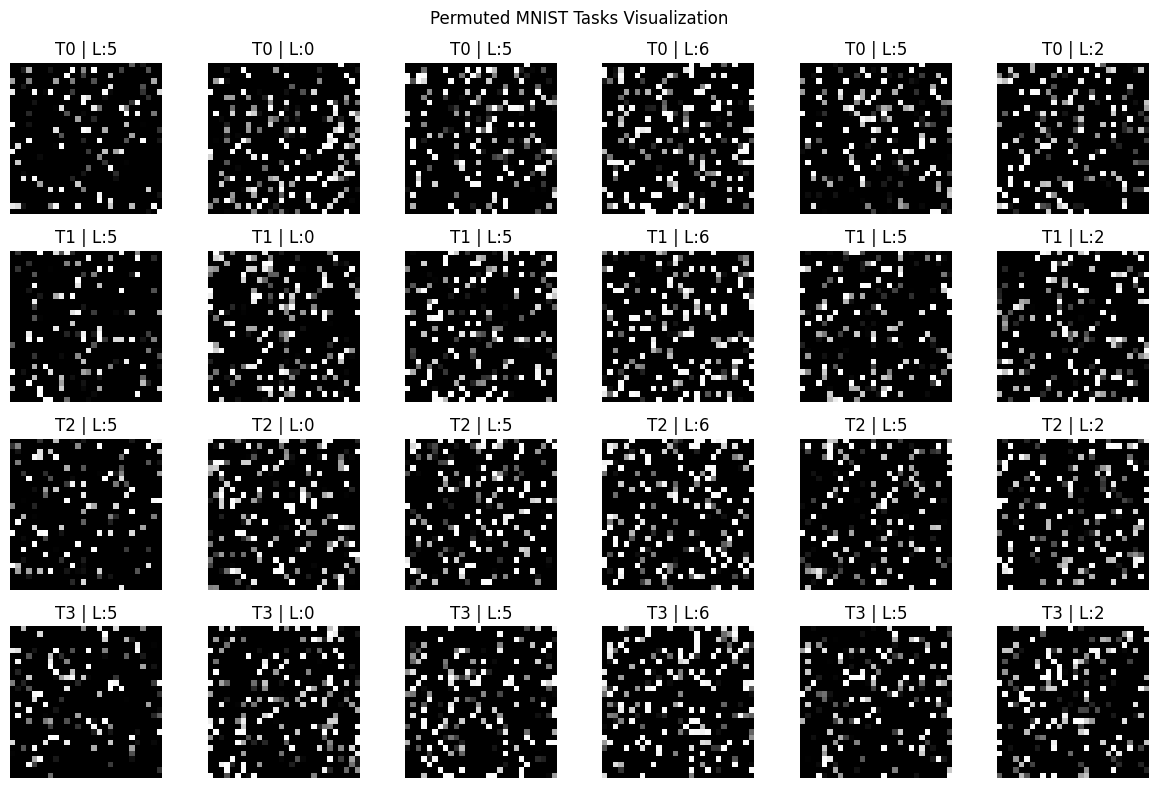

In [ ]:
visualize_tasks(tasks, num_tasks=4, num_images=6)


In [ ]:
############################################
# RUN ALL EXPERIMENTS
############################################

n_experiment_tasks = 5

baseline_runs = []
ewc_runs = []
l2_runs = []

############################################
# BASELINE
############################################

print("\n========================================")
print(" STARTING BASELINE EXPERIMENT ")
print("========================================")

mnist_model.apply(weights_init)

for t in range(n_experiment_tasks):

    eval_perms = tasks[:t+1]

    print("\n----------------------------------------")
    print(f"Training Task {t+1}/{n_experiment_tasks}  [BASELINE]")
    print(f"Training permutation: Task {t}")
    print(f"Testing on tasks: {[i for i in range(t+1)]}")
    print("----------------------------------------")

    run = train(
        t,
        tasks[t],
        eval_perms
    )

    baseline_runs.append(run)


 STARTING BASELINE EXPERIMENT 

----------------------------------------
Training Task 1/5  [BASELINE]
Training permutation: Task 0
Testing on tasks: [0]
----------------------------------------

CHECKPOINT FOUND
Resuming from Epoch 5/5

Results until last saved epoch:


----- Epoch 1/5 -----
Training Loss: 0.5920
Test Accuracy Task 0: 92.80%

----- Epoch 2/5 -----
Training Loss: 0.2092
Test Accuracy Task 0: 95.00%

----- Epoch 3/5 -----
Training Loss: 0.1455
Test Accuracy Task 0: 95.95%

----- Epoch 4/5 -----
Training Loss: 0.1147
Test Accuracy Task 0: 96.57%

----- Epoch 5/5 -----
Training Loss: 0.0933
Test Accuracy Task 0: 96.87%

RESUMING TRAINING...

Training already completed.

Final Results from checkpoint:
Final Training Loss: 0.0933
Task 0 Final Test Accuracy: 96.87%

----------------------------------------
Training Task 2/5  [BASELINE]
Training permutation: Task 1
Testing on tasks: [0, 1]
----------------------------------------

CHECKPOINT FOUND
Resuming from Epoch 5/5

Re

In [ ]:



############################################
# EWC
############################################

print("\n========================================")
print(" STARTING EWC EXPERIMENT ")
print("========================================")

mnist_model.apply(weights_init)

fims = []
old_models = []

for t in range(n_experiment_tasks):

    eval_perms = tasks[:t+1]

    print("\n----------------------------------------")
    print(f"Training Task {t+1}/{n_experiment_tasks}  [EWC]")
    print(f"Training permutation: Task {t}")
    print(f"Testing on tasks: {[i for i in range(t+1)]}")
    print("----------------------------------------")

    run = train(
        t,
        tasks[t],
        eval_perms,
        use_ewc=(t > 0),
        fims=fims if t > 0 else None,
        old_state_dicts=old_models if t > 0 else None
    )

    ewc_runs.append(run)

    print("Calculating Fisher Information Matrix...")
    fim, model_state = calculate_fim(mnist_model, tasks[t])

    fims.append(fim)
    old_models.append(model_state)

    print("FIM stored for future tasks.")


 STARTING EWC EXPERIMENT 

----------------------------------------
Training Task 1/5  [EWC]
Training permutation: Task 0
Testing on tasks: [0]
----------------------------------------

CHECKPOINT FOUND
Resuming from Epoch 5/5

Results until last saved epoch:


----- Epoch 1/5 -----
Training Loss: 0.5920
Test Accuracy Task 0: 92.80%

----- Epoch 2/5 -----
Training Loss: 0.2092
Test Accuracy Task 0: 95.00%

----- Epoch 3/5 -----
Training Loss: 0.1455
Test Accuracy Task 0: 95.95%

----- Epoch 4/5 -----
Training Loss: 0.1147
Test Accuracy Task 0: 96.57%

----- Epoch 5/5 -----
Training Loss: 0.0933
Test Accuracy Task 0: 96.87%

RESUMING TRAINING...

Training already completed.

Final Results from checkpoint:
Final Training Loss: 0.0933
Task 0 Final Test Accuracy: 96.87%
Calculating Fisher Information Matrix...


  0%|          | 0/60000 [00:00<?, ?it/s]

FIM stored for future tasks.

----------------------------------------
Training Task 2/5  [EWC]
Training permutation: Task 1
Testing on tasks: [0, 1]
----------------------------------------

CHECKPOINT FOUND
Resuming from Epoch 5/5

Results until last saved epoch:


----- Epoch 1/5 -----
Training Loss: 0.5414
Test Accuracy Task 0: 89.31%
Test Accuracy Task 1: 93.95%

----- Epoch 2/5 -----
Training Loss: 0.2257
Test Accuracy Task 0: 92.02%
Test Accuracy Task 1: 95.38%

----- Epoch 3/5 -----
Training Loss: 0.1714
Test Accuracy Task 0: 93.86%
Test Accuracy Task 1: 96.20%

----- Epoch 4/5 -----
Training Loss: 0.1446
Test Accuracy Task 0: 94.53%
Test Accuracy Task 1: 96.48%

----- Epoch 5/5 -----
Training Loss: 0.1267
Test Accuracy Task 0: 95.14%
Test Accuracy Task 1: 96.69%

RESUMING TRAINING...

Training already completed.

Final Results from checkpoint:
Final Training Loss: 0.1267
Task 0 Final Test Accuracy: 95.14%
Task 1 Final Test Accuracy: 96.69%
Calculating Fisher Information Matrix

  0%|          | 0/60000 [00:00<?, ?it/s]

FIM stored for future tasks.

----------------------------------------
Training Task 3/5  [EWC]
Training permutation: Task 2
Testing on tasks: [0, 1, 2]
----------------------------------------

CHECKPOINT FOUND
Resuming from Epoch 5/5

Results until last saved epoch:


----- Epoch 1/5 -----
Training Loss: 0.5967
Test Accuracy Task 0: 88.51%
Test Accuracy Task 1: 91.92%
Test Accuracy Task 2: 94.32%

----- Epoch 2/5 -----
Training Loss: 0.2634
Test Accuracy Task 0: 91.67%
Test Accuracy Task 1: 94.47%
Test Accuracy Task 2: 95.38%

----- Epoch 3/5 -----
Training Loss: 0.2046
Test Accuracy Task 0: 93.75%
Test Accuracy Task 1: 95.60%
Test Accuracy Task 2: 96.19%

----- Epoch 4/5 -----
Training Loss: 0.1780
Test Accuracy Task 0: 94.11%
Test Accuracy Task 1: 95.68%
Test Accuracy Task 2: 96.40%

----- Epoch 5/5 -----
Training Loss: 0.1582
Test Accuracy Task 0: 94.73%
Test Accuracy Task 1: 95.93%
Test Accuracy Task 2: 96.76%

RESUMING TRAINING...

Training already completed.

Final Results from

...

FIM stored for future tasks.

----------------------------------------
Training Task 4/5  [EWC]
Training permutation: Task 3
Testing on tasks: [0, 1, 2, 3]
----------------------------------------

CHECKPOINT FOUND
Resuming from Epoch 5/5

Results until last saved epoch:


----- Epoch 1/5 -----
Training Loss: 0.7021
Test Accuracy Task 0: 89.09%
Test Accuracy Task 1: 92.97%
Test Accuracy Task 2: 90.71%
Test Accuracy Task 3: 94.06%

----- Epoch 2/5 -----
Training Loss: 0.3209
Test Accuracy Task 0: 93.78%
Test Accuracy Task 1: 94.66%
Test Accuracy Task 2: 94.72%
Test Accuracy Task 3: 95.39%

----- Epoch 3/5 -----
Training Loss: 0.2502
Test Accuracy Task 0: 94.81%
Test Accuracy Task 1: 95.05%
Test Accuracy Task 2: 95.30%
Test Accuracy Task 3: 96.03%

----- Epoch 4/5 -----
Training Loss: 0.2179
Test Accuracy Task 0: 95.15%
Test Accuracy Task 1: 95.28%
Test Accuracy Task 2: 94.99%
Test Accuracy Task 3: 96.19%

----- Epoch 5/5 -----
Training Loss: 0.1999
Test Accuracy Task 0: 95.12%
Test Accu

  0%|          | 0/60000 [00:00<?, ?it/s]

FIM stored for future tasks.

----------------------------------------
Training Task 5/5  [EWC]
Training permutation: Task 4
Testing on tasks: [0, 1, 2, 3, 4]
----------------------------------------

CHECKPOINT FOUND
Resuming from Epoch 5/5

Results until last saved epoch:


----- Epoch 1/5 -----
Training Loss: 0.8050
Test Accuracy Task 0: 90.37%
Test Accuracy Task 1: 94.16%
Test Accuracy Task 2: 87.98%
Test Accuracy Task 3: 91.89%
Test Accuracy Task 4: 94.22%

----- Epoch 2/5 -----
Training Loss: 0.3660
Test Accuracy Task 0: 94.35%
Test Accuracy Task 1: 95.31%
Test Accuracy Task 2: 93.00%
Test Accuracy Task 3: 94.95%
Test Accuracy Task 4: 95.54%

----- Epoch 3/5 -----
Training Loss: 0.2893
Test Accuracy Task 0: 95.46%
Test Accuracy Task 1: 95.32%
Test Accuracy Task 2: 93.50%
Test Accuracy Task 3: 95.09%
Test Accuracy Task 4: 95.91%

----- Epoch 4/5 -----
Training Loss: 0.2577
Test Accuracy Task 0: 95.34%
Test Accuracy Task 1: 95.37%
Test Accuracy Task 2: 94.06%
Test Accuracy Task 3: 

  0%|          | 0/60000 [00:00<?, ?it/s]

FIM stored for future tasks.


In [ ]:
############################################
# L2
############################################

print("\n========================================")
print(" STARTING L2 REGULARIZATION EXPERIMENT ")
print("========================================")

mnist_model.apply(weights_init)

old_state_dicts = []

for t in range(n_experiment_tasks):

    eval_perms = tasks[:t+1]

    print("\n----------------------------------------")
    print(f"Training Task {t+1}/{n_experiment_tasks}  [L2]")
    print(f"Training permutation: Task {t}")
    print(f"Testing on tasks: {[i for i in range(t+1)]}")
    print("----------------------------------------")

    run = train(
        t,
        tasks[t],
        eval_perms,
        use_l2=(t > 0),
        old_state_dicts=old_state_dicts if t > 0 else None,
        l2_lambda=0.1
    )

    l2_runs.append(run)

    ########################################
    # SAVE MODEL AFTER TASK
    ########################################

    old_state_dicts.append({
        name: param.clone().detach()
        for name, param in mnist_model.named_parameters()
    })


print("\n========================================")
print(" ALL EXPERIMENTS COMPLETED ")
print("========================================")


 STARTING L2 REGULARIZATION EXPERIMENT 

----------------------------------------
Training Task 1/5  [L2]
Training permutation: Task 0
Testing on tasks: [0]
----------------------------------------

CHECKPOINT FOUND
Resuming from Epoch 5/5

Results until last saved epoch:


----- Epoch 1/5 -----
Training Loss: 0.5920
Test Accuracy Task 0: 92.80%

----- Epoch 2/5 -----
Training Loss: 0.2092
Test Accuracy Task 0: 95.00%

----- Epoch 3/5 -----
Training Loss: 0.1455
Test Accuracy Task 0: 95.95%

----- Epoch 4/5 -----
Training Loss: 0.1147
Test Accuracy Task 0: 96.57%

----- Epoch 5/5 -----
Training Loss: 0.0933
Test Accuracy Task 0: 96.87%

RESUMING TRAINING...

Training already completed.

Final Results from checkpoint:
Final Training Loss: 0.0933
Task 0 Final Test Accuracy: 96.87%

----------------------------------------
Training Task 2/5  [L2]
Training permutation: Task 1
Testing on tasks: [0, 1]
----------------------------------------

CHECKPOINT FOUND
Resuming from Epoch 5/5

Resul

In [ ]:
############################################
# MAS
############################################

print("\n========================================")
print(" STARTING MAS EXPERIMENT ")
print("========================================")

mnist_model.apply(weights_init)

mas_runs = []
mas_importances = []
old_models_mas = []

for t in range(n_experiment_tasks):

    eval_perms = tasks[:t+1]

    print("\n----------------------------------------")
    print(f"Training Task {t+1}/{n_experiment_tasks}  [MAS]")
    print(f"Training permutation: Task {t}")
    print(f"Testing on tasks: {[i for i in range(t+1)]}")
    print("----------------------------------------")

    run = train(
        t,
        tasks[t],
        eval_perms,
        use_mas=(t > 0),
        mas_importances=mas_importances if t > 0 else None,
        old_state_dicts=old_models_mas if t > 0 else None
    )

    mas_runs.append(run)

    print("Calculating MAS importance...")
    mas_imp, model_state = calculate_mas_importance(mnist_model, tasks[t])

    mas_importances.append(mas_imp)
    old_models_mas.append(model_state)

    print("MAS importance stored for future tasks.")


 STARTING MAS EXPERIMENT 

----------------------------------------
Training Task 1/5  [MAS]
Training permutation: Task 0
Testing on tasks: [0]
----------------------------------------

CHECKPOINT FOUND
Resuming from Epoch 5/5

Results until last saved epoch:


----- Epoch 1/5 -----
Training Loss: 0.5920
Test Accuracy Task 0: 92.80%

----- Epoch 2/5 -----
Training Loss: 0.2092
Test Accuracy Task 0: 95.00%

----- Epoch 3/5 -----
Training Loss: 0.1455
Test Accuracy Task 0: 95.95%

----- Epoch 4/5 -----
Training Loss: 0.1147
Test Accuracy Task 0: 96.57%

----- Epoch 5/5 -----
Training Loss: 0.0933
Test Accuracy Task 0: 96.87%

RESUMING TRAINING...

Training already completed.

Final Results from checkpoint:
Final Training Loss: 0.0933
Task 0 Final Test Accuracy: 96.87%
Calculating MAS importance...


  0%|          | 0/60000 [00:00<?, ?it/s]

MAS importance stored for future tasks.

----------------------------------------
Training Task 2/5  [MAS]
Training permutation: Task 1
Testing on tasks: [0, 1]
----------------------------------------

EPOCH 1/5

--- TRAINING (computing training loss) ---

--- TEST ACCURACY (on evaluation tasks) ---
Task 0 accuracy: 96.84%
Task 1 accuracy: 92.59%
Test Accuracy Task 0: 96.84%
Test Accuracy Task 1: 92.59%

--- EPOCH SUMMARY ---
Average Training Loss: 0.7907
Epoch Training Time: 11.98 seconds

EPOCH 2/5

--- TRAINING (computing training loss) ---

--- TEST ACCURACY (on evaluation tasks) ---
Task 0 accuracy: 96.77%
Task 1 accuracy: 93.65%
Test Accuracy Task 0: 96.77%
Test Accuracy Task 1: 93.65%

--- EPOCH SUMMARY ---
Average Training Loss: 0.3043
Epoch Training Time: 11.54 seconds

EPOCH 3/5

--- TRAINING (computing training loss) ---

--- TEST ACCURACY (on evaluation tasks) ---
Task 0 accuracy: 96.90%
Task 1 accuracy: 94.57%
Test Accuracy Task 0: 96.90%
Test Accuracy Task 1: 94.57%

---

  0%|          | 0/60000 [00:00<?, ?it/s]

MAS importance stored for future tasks.

----------------------------------------
Training Task 3/5  [MAS]
Training permutation: Task 2
Testing on tasks: [0, 1, 2]
----------------------------------------

EPOCH 1/5

--- TRAINING (computing training loss) ---

--- TEST ACCURACY (on evaluation tasks) ---
Task 0 accuracy: 96.86%
Task 1 accuracy: 95.38%
Task 2 accuracy: 89.76%
Test Accuracy Task 0: 96.86%
Test Accuracy Task 1: 95.38%
Test Accuracy Task 2: 89.76%

--- EPOCH SUMMARY ---
Average Training Loss: 1.0683
Epoch Training Time: 13.36 seconds

EPOCH 2/5

--- TRAINING (computing training loss) ---

--- TEST ACCURACY (on evaluation tasks) ---
Task 0 accuracy: 96.82%
Task 1 accuracy: 95.35%
Task 2 accuracy: 91.63%
Test Accuracy Task 0: 96.82%
Test Accuracy Task 1: 95.35%
Test Accuracy Task 2: 91.63%

--- EPOCH SUMMARY ---
Average Training Loss: 0.5261
Epoch Training Time: 13.36 seconds

EPOCH 3/5

--- TRAINING (computing training loss) ---

--- TEST ACCURACY (on evaluation tasks) ---
T

...

MAS importance stored for future tasks.

----------------------------------------
Training Task 4/5  [MAS]
Training permutation: Task 3
Testing on tasks: [0, 1, 2, 3]
----------------------------------------

EPOCH 1/5

--- TRAINING (computing training loss) ---

--- TEST ACCURACY (on evaluation tasks) ---
Task 0 accuracy: 96.77%
Task 1 accuracy: 95.14%
Task 2 accuracy: 93.29%
Task 3 accuracy: 86.56%
Test Accuracy Task 0: 96.77%
Test Accuracy Task 1: 95.14%
Test Accuracy Task 2: 93.29%
Test Accuracy Task 3: 86.56%

--- EPOCH SUMMARY ---
Average Training Loss: 1.3772
Epoch Training Time: 15.61 seconds

EPOCH 2/5

--- TRAINING (computing training loss) ---

--- TEST ACCURACY (on evaluation tasks) ---
Task 0 accuracy: 96.74%
Task 1 accuracy: 95.19%
Task 2 accuracy: 93.43%
Task 3 accuracy: 88.79%
Test Accuracy Task 0: 96.74%
Test Accuracy Task 1: 95.19%
Test Accuracy Task 2: 93.43%
Test Accuracy Task 3: 88.79%

--- EPOCH SUMMARY ---
Average Training Loss: 0.7914
Epoch Training Time: 15.27 

  0%|          | 0/60000 [00:00<?, ?it/s]

MAS importance stored for future tasks.

----------------------------------------
Training Task 5/5  [MAS]
Training permutation: Task 4
Testing on tasks: [0, 1, 2, 3, 4]
----------------------------------------

EPOCH 1/5

--- TRAINING (computing training loss) ---

--- TEST ACCURACY (on evaluation tasks) ---
Task 0 accuracy: 96.83%
Task 1 accuracy: 94.92%
Task 2 accuracy: 93.06%
Task 3 accuracy: 89.66%
Task 4 accuracy: 80.11%
Test Accuracy Task 0: 96.83%
Test Accuracy Task 1: 94.92%
Test Accuracy Task 2: 93.06%
Test Accuracy Task 3: 89.66%
Test Accuracy Task 4: 80.11%

--- EPOCH SUMMARY ---
Average Training Loss: 1.8625
Epoch Training Time: 17.06 seconds

EPOCH 2/5

--- TRAINING (computing training loss) ---

--- TEST ACCURACY (on evaluation tasks) ---
Task 0 accuracy: 96.77%
Task 1 accuracy: 94.81%
Task 2 accuracy: 92.73%
Task 3 accuracy: 88.75%
Task 4 accuracy: 82.93%
Test Accuracy Task 0: 96.77%
Test Accuracy Task 1: 94.81%
Test Accuracy Task 2: 92.73%
Test Accuracy Task 3: 88.75%


  0%|          | 0/60000 [00:00<?, ?it/s]

MAS importance stored for future tasks.


In [ ]:
############################################
# SI
############################################

print("\n========================================")
print(" STARTING SI EXPERIMENT ")
print("========================================")

mnist_model.apply(weights_init)

si_runs = []
si_omegas = []
old_models_si = []

# initialize SI buffers once for the current model
omega, W, prev_params, start_params = si_init_buffers(mnist_model)

for t in range(n_experiment_tasks):

    eval_perms = tasks[:t+1]

    print("\n----------------------------------------")
    print(f"Training Task {t+1}/{n_experiment_tasks}  [SI]")
    print(f"Training permutation: Task {t}")
    print(f"Testing on tasks: {[i for i in range(t+1)]}")
    print("----------------------------------------")

    run = train(
        t,
        tasks[t],
        eval_perms,
        use_si=(t > 0),
        si_omegas=si_omegas if t > 0 else None,
        old_state_dicts=old_models_si if t > 0 else None,
        si_prev_params=prev_params,
        si_W=W,
        si_start_params=start_params
    )

    si_runs.append(run)

    print("Finalizing SI importance...")
    omega, old_model = si_finalize_importance(
        mnist_model, omega, W, start_params, epsilon=si_epsilon
    )

    si_omegas.append(deepcopy(omega))
    old_models_si.append(deepcopy(old_model))

    # reset trajectory buffers for next task
    _, W, prev_params, start_params = si_init_buffers(mnist_model)

    print("SI importance stored for future tasks.")


 STARTING SI EXPERIMENT 

----------------------------------------
Training Task 1/5  [SI]
Training permutation: Task 0
Testing on tasks: [0]
----------------------------------------

CHECKPOINT FOUND
Resuming from Epoch 5/5

Results until last saved epoch:


----- Epoch 1/5 -----
Training Loss: 0.5920
Test Accuracy Task 0: 92.80%

----- Epoch 2/5 -----
Training Loss: 0.2092
Test Accuracy Task 0: 95.00%

----- Epoch 3/5 -----
Training Loss: 0.1455
Test Accuracy Task 0: 95.95%

----- Epoch 4/5 -----
Training Loss: 0.1147
Test Accuracy Task 0: 96.57%

----- Epoch 5/5 -----
Training Loss: 0.0933
Test Accuracy Task 0: 96.87%

RESUMING TRAINING...

Training already completed.

Final Results from checkpoint:
Final Training Loss: 0.0933
Task 0 Final Test Accuracy: 96.87%
Finalizing SI importance...
SI importance stored for future tasks.

----------------------------------------
Training Task 2/5  [SI]
Training permutation: Task 1
Testing on tasks: [0, 1]
-------------------------------------

Final Accuracies:
---

In [ ]:
############################################
# BASELINE EVALUATION
############################################

print("\n==============================")
print("BASELINE RESULTS")
print("==============================")

final_acc = baseline_runs[-1][:, -1] * 100

for i, acc in enumerate(final_acc):
    print(f"Task {i} Final Accuracy: {acc:.2f}%")

avg_acc = final_acc.mean()

print(f"\nAverage Accuracy (Baseline): {avg_acc:.2f}%")


BASELINE RESULTS
Task 0 Final Accuracy: 26.11%
Task 1 Final Accuracy: 50.60%
Task 2 Final Accuracy: 33.11%
Task 3 Final Accuracy: 72.47%
Task 4 Final Accuracy: 97.15%

Average Accuracy (Baseline): 55.89%


In [ ]:
############################################
# EWC EVALUATION
############################################

print("\n==============================")
print("EWC RESULTS")
print("==============================")

final_acc = ewc_runs[-1][:, -1] * 100

for i, acc in enumerate(final_acc):
    print(f"Task {i} Final Accuracy: {acc:.2f}%")

avg_acc = final_acc.mean()

print(f"\nAverage Accuracy (EWC): {avg_acc:.2f}%")


EWC RESULTS
Task 0 Final Accuracy: 95.85%
Task 1 Final Accuracy: 95.17%
Task 2 Final Accuracy: 94.30%
Task 3 Final Accuracy: 94.89%
Task 4 Final Accuracy: 96.39%

Average Accuracy (EWC): 95.32%


In [ ]:
############################################
# MAS EVALUATION
############################################

print("\n==============================")
print("MAS RESULTS")
print("==============================")

final_acc = mas_runs[-1][:, -1] * 100

for i, acc in enumerate(final_acc):
    print(f"Task {i} Final Accuracy: {acc:.2f}%")

avg_acc = final_acc.mean()
print(f"\nAverage Accuracy (MAS): {avg_acc:.2f}%")


MAS RESULTS
Task 0 Final Accuracy: 96.16%
Task 1 Final Accuracy: 94.42%
Task 2 Final Accuracy: 91.21%
Task 3 Final Accuracy: 81.94%
Task 4 Final Accuracy: 87.27%

Average Accuracy (MAS): 90.20%


In [ ]:
############################################
# SI EVALUATION
############################################

print("\n==============================")
print("SI RESULTS")
print("==============================")

final_acc = si_runs[-1][:, -1] * 100

for i, acc in enumerate(final_acc):
    print(f"Task {i} Final Accuracy: {acc:.2f}%")

avg_acc = final_acc.mean()
print(f"\nAverage Accuracy (SI): {avg_acc:.2f}%")


SI RESULTS
Task 0 Final Accuracy: 39.09%
Task 1 Final Accuracy: 77.09%
Task 2 Final Accuracy: 69.77%
Task 3 Final Accuracy: 88.08%
Task 4 Final Accuracy: 97.30%

Average Accuracy (SI): 74.27%


In [ ]:
############################################
# L2 EVALUATION
############################################

print("\n==============================")
print("L2 RESULTS")
print("==============================")

final_acc = l2_runs[-1][:, -1] * 100

for i, acc in enumerate(final_acc):
    print(f"Task {i} Final Accuracy: {acc:.2f}%")

avg_acc = final_acc.mean()

print(f"\nAverage Accuracy (L2): {avg_acc:.2f}%")


L2 RESULTS
Task 0 Final Accuracy: 95.26%
Task 1 Final Accuracy: 57.75%
Task 2 Final Accuracy: 34.73%
Task 3 Final Accuracy: 19.14%
Task 4 Final Accuracy: 78.42%

Average Accuracy (L2): 57.06%


In [ ]:
def plot_sequential_accuracy(all_runs, title):

    total_tasks = len(all_runs)
    total_epochs = epochs * total_tasks

    padded_runs = []

    for task_id, run in enumerate(all_runs):

        left_pad = task_id * epochs
        right_pad = total_epochs - left_pad - epochs
        bottom_pad = total_tasks - run.shape[0]

        padded = torch.nn.functional.pad(
            run,
            (left_pad, right_pad, 0, bottom_pad)
        )

        padded_runs.append(padded)

    concat_runs = sum(padded_runs)

    labels = [f'Task {i}' for i in range(concat_runs.shape[0])]

    plt.figure(figsize=(10,6))

    for idx, task_acc in enumerate(concat_runs):

        plt.plot(task_acc.T, label=labels[idx])

        final_epoch = task_acc.shape[0] - 1
        final_acc = task_acc[-1].item() * 100

        plt.text(
            final_epoch,
            task_acc[-1].item(),
            f'{final_acc:.1f}%',
            fontsize=10,
            verticalalignment='bottom'
        )

    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.show()

/tmp/ipykernel_303/3609400785.py:29: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4480.)
  plt.plot(task_acc.T, label=labels[idx])


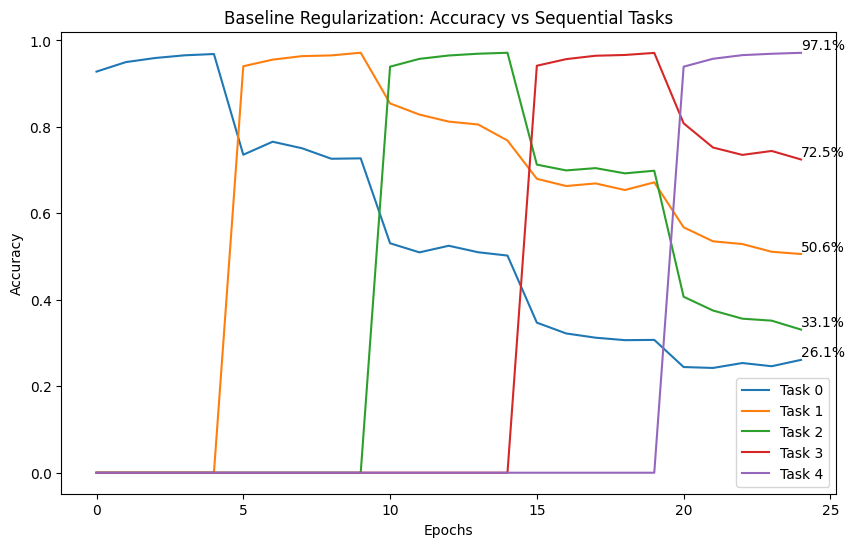

In [ ]:
plot_sequential_accuracy(baseline_runs[-5:], "Baseline Regularization: Accuracy vs Sequential Tasks")

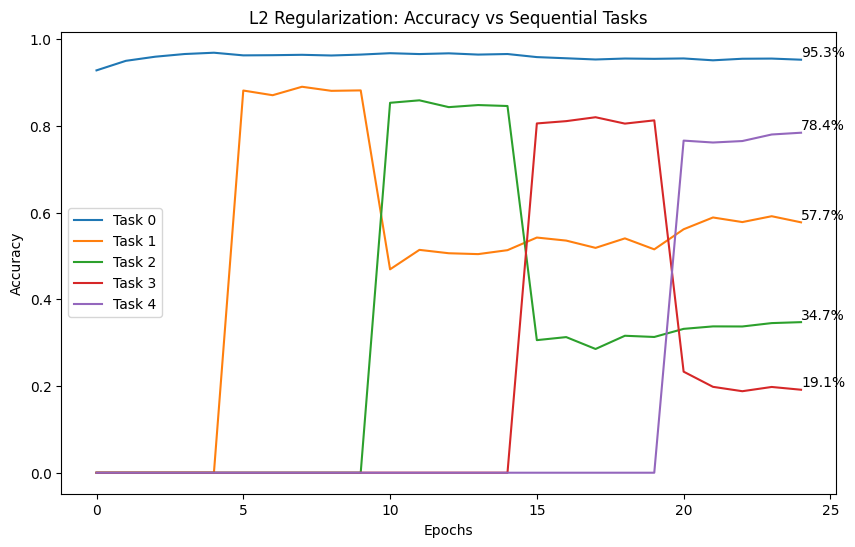

In [ ]:
plot_sequential_accuracy(l2_runs[-5:], "L2 Regularization: Accuracy vs Sequential Tasks")

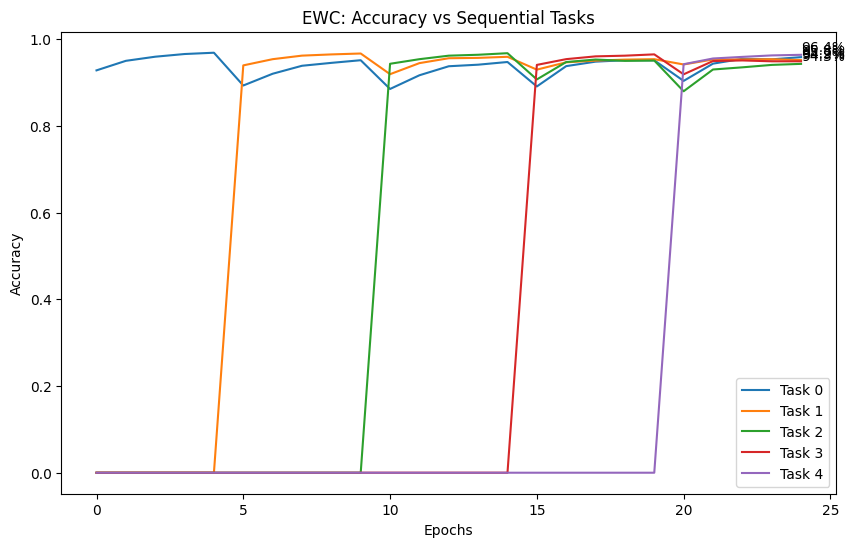

In [ ]:
plot_sequential_accuracy(ewc_runs[-5:], "EWC: Accuracy vs Sequential Tasks")

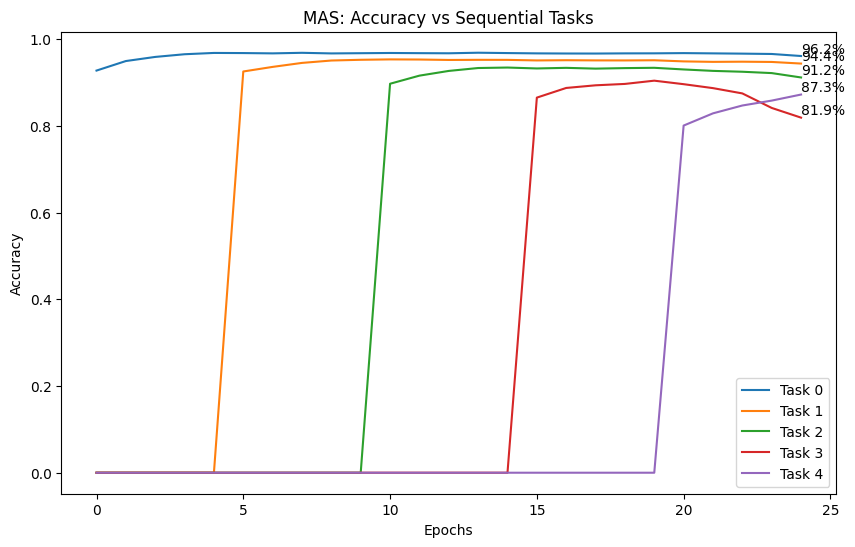

In [ ]:
plot_sequential_accuracy(mas_runs[-5:], "MAS: Accuracy vs Sequential Tasks")

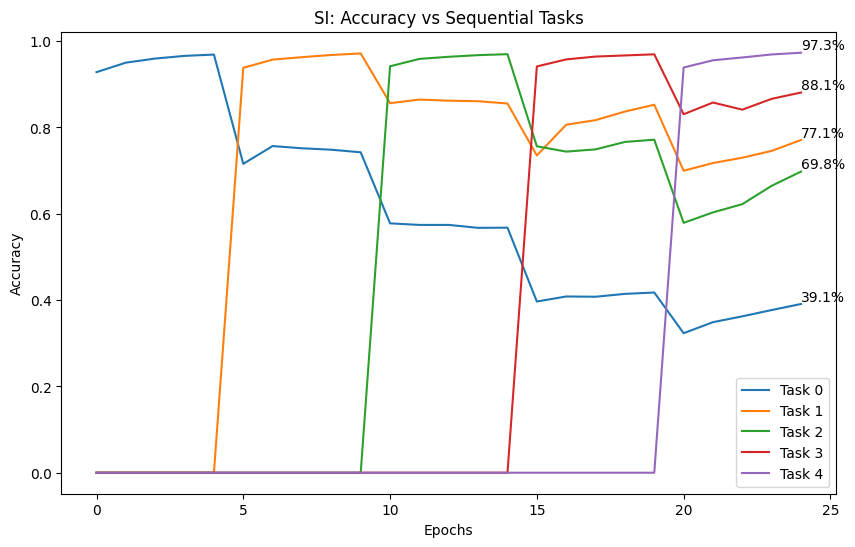

In [ ]:
plot_sequential_accuracy(si_runs[-5:], "SI: Accuracy vs Sequential Tasks")
